In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32793,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39077,Total threads: 8
Dashboard: http://127.0.0.1:33223/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:44857,


In [2]:
iter = 18
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/nov2012/validate_fwd/iter' + str(iter) + '/'

In [3]:
import xarray as xr
profile_path = '/data/SO3/edavenport/tpose6/nov2012/run_ad/PROF_eq/TAO_WO_2012_CTD_daily_model.nc'
ds_ctd_2012 = xr.open_dataset(profile_path)
profile_path = '/data/SO3/edavenport/tpose6/nov2012/run_ad/PROF_eq/TAO_WO_2013_CTD_daily_model.nc'
ds_ctd_2013 = xr.open_dataset(profile_path)

ds_ctd = xr.concat([ds_ctd_2012, ds_ctd_2013],dim='iPROF')

/tmp/ipykernel_1024039/1194128078.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_ctd = xr.concat([ds_ctd_2012, ds_ctd_2013],dim='iPROF')


In [4]:
ds_ctd

<xarray.Dataset> Size: 74MB
Dimensions:        (iPROF: 31969, iDEPTH: 40)
Dimensions without coordinates: iPROF, iDEPTH
Data variables:
    prof_YYYYMMDD  (iPROF) float64 256kB 2.012e+07 2.012e+07 ... 2.013e+07
    prof_HHMMSS    (iPROF) float64 256kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    prof_lon       (iPROF) float64 256kB -110.0 -110.0 -110.0 ... -140.0 -140.0
    prof_lat       (iPROF) float64 256kB 0.0 0.0 0.0 0.0 0.0 ... 9.0 9.0 9.0 9.0
    prof_depth     (iPROF, iDEPTH) float64 10MB 1.0 2.0 5.0 ... 400.0 500.0
    prof_descr     (iPROF) |S30 959kB b's0n110w_dy.cdf                ' ... b...
    prof_T         (iPROF, iDEPTH) float64 10MB 22.68 nan 22.59 ... nan 7.628
    prof_Tweight   (iPROF, iDEPTH) float64 10MB 2.953 0.0 2.833 ... 0.0 25.72
    prof_S         (iPROF, iDEPTH) float64 10MB 34.83 nan nan ... nan nan nan
    prof_Sweight   (iPROF, iDEPTH) float64 10MB 30.93 0.0 0.0 ... 0.0 0.0 0.0
    prof_Testim    (iPROF, iDEPTH) float64 10MB nan nan nan nan ... nan nan nan
    prof_Sestim    (iPROF, iDEPTH) float64 10MB nan nan nan nan ... nan nan nan
Attributes:
    Format:   The contents of this MITprof file were processed \nusing the MI...
    date:     05-Jan-2026

In [5]:
import pandas as pd
# Combine date and time into a datetime array
dates = ds_ctd['prof_YYYYMMDD'].values.astype(int)
times = ds_ctd['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_ctd = ds_ctd.assign_coords(time=('iPROF', datetimes))
# ds_ctd = ds_ctd.swap_dims({'iPROF': 'time'})
ds_ctd = ds_ctd.assign_coords(depth=('iDEPTH', ds_ctd['prof_depth'][0,:].values*-1))
# ds_ctd = ds_ctd.swap_dims({'iDEPTH': 'depth'})
ds_ctd = ds_ctd.assign_coords(lat=('iPROF', ds_ctd['prof_lat'].values))
ds_ctd = ds_ctd.assign_coords(lon=('iPROF', ds_ctd['prof_lon'].values))

In [6]:
import numpy as np
# validate TAO profiles, calculate the weight associated with each profile and plot v profile ID
# Residuals
rT = ds_ctd.prof_T - ds_ctd.prof_Testim          # (IDEPTH, IPROF)
rS = ds_ctd.prof_S - ds_ctd.prof_Sestim

# Costs per profile (sum over depth axis = 0)
J_T = (ds_ctd.prof_Tweight * rT**2).sum(dim='iDEPTH')   # (IPROF,)
J_S = (ds_ctd.prof_Sweight * rS**2).sum(dim='iDEPTH')   # (IPROF,)

# Combined cost
J_TS = J_T + J_S

In [7]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib.colors import TwoSlopeNorm
import cmocean.cm as cmo
warnings.filterwarnings("ignore")
plt.rcParams['font.size'] = 15


In [11]:
J_T

<xarray.DataArray (iPROF: 31969)> Size: 256kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(31969,))
Coordinates:
    time     (iPROF) datetime64[ns] 256kB 2012-01-01 2012-01-02 ... 2013-12-31
    lat      (iPROF) float64 256kB 0.0 0.0 0.0 0.0 0.0 ... 9.0 9.0 9.0 9.0 9.0
    lon      (iPROF) float64 256kB -110.0 -110.0 -110.0 ... -140.0 -140.0 -140.0
Dimensions without coordinates: iPROF
Attributes:
    long_name:  pot. temp. least-square weight

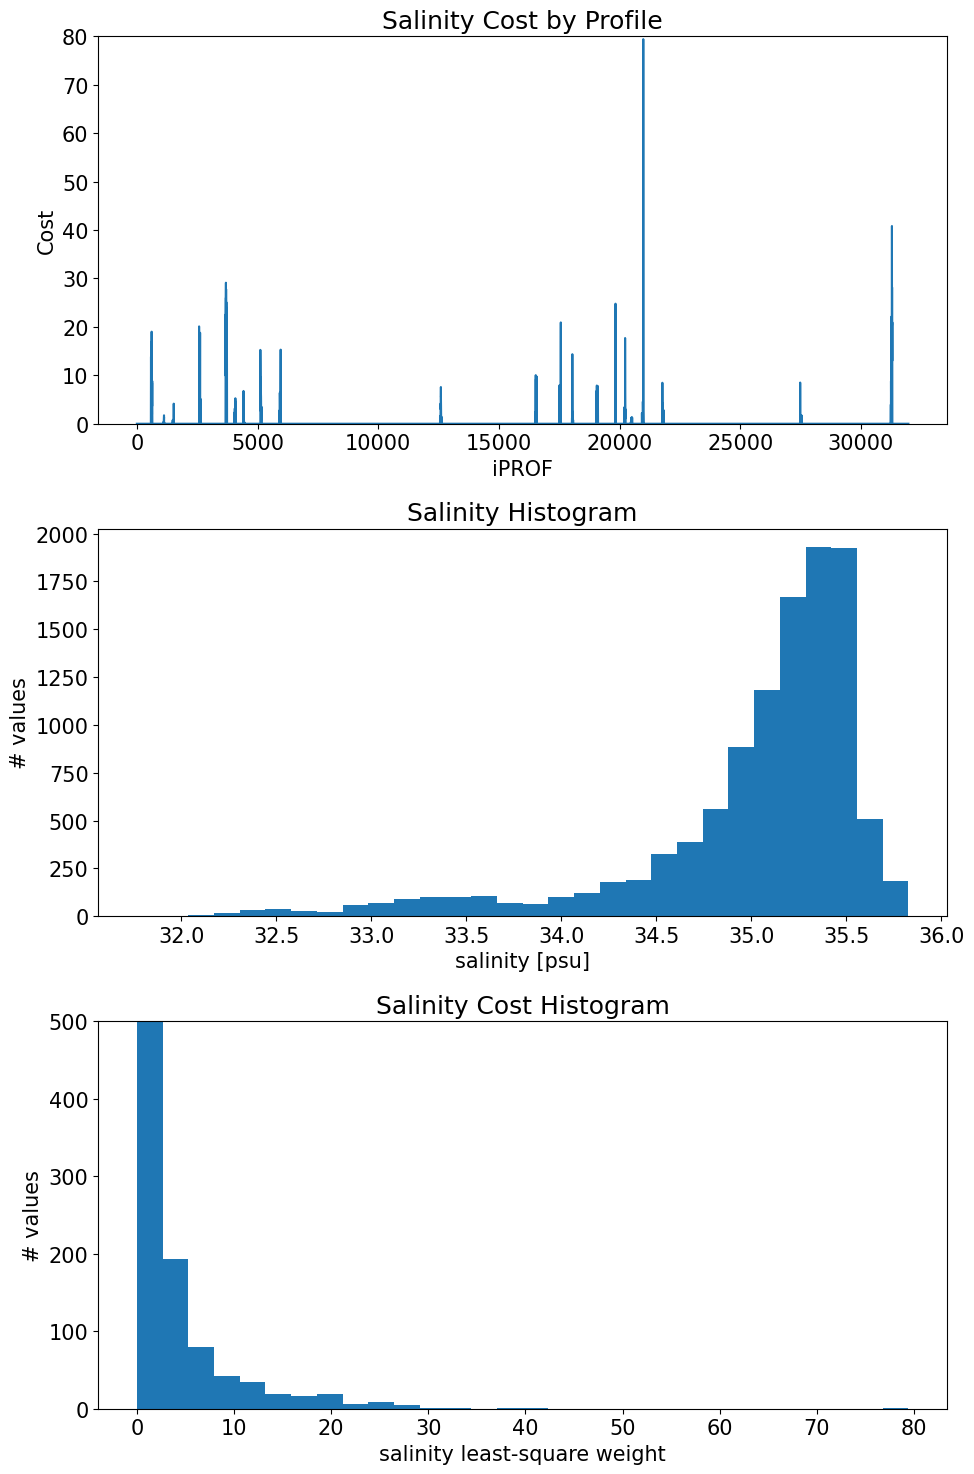

In [9]:
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(10,15))
J_S.plot(ax=ax[0])
ax[0].set_ylim(0,80)
ax[0].set_title('Salinity Cost by Profile')
ax[0].set_ylabel('Cost')

ds_ctd.prof_S.plot.hist(ax=ax[1],bins=30)
# ax[1].set_ylim(0,80)
ax[1].set_title('Salinity Histogram')
ax[1].set_ylabel('# values')

J_S.plot.hist(ax=ax[2],bins=30)
ax[2].set_title('Salinity Cost Histogram')
ax[2].set_ylabel('# values')
ax[2].set_ylim(0,500)
plt.tight_layout()
fig.savefig(foldername + 'TAO_salinity_cost_iter' + str(iter) + '.png')

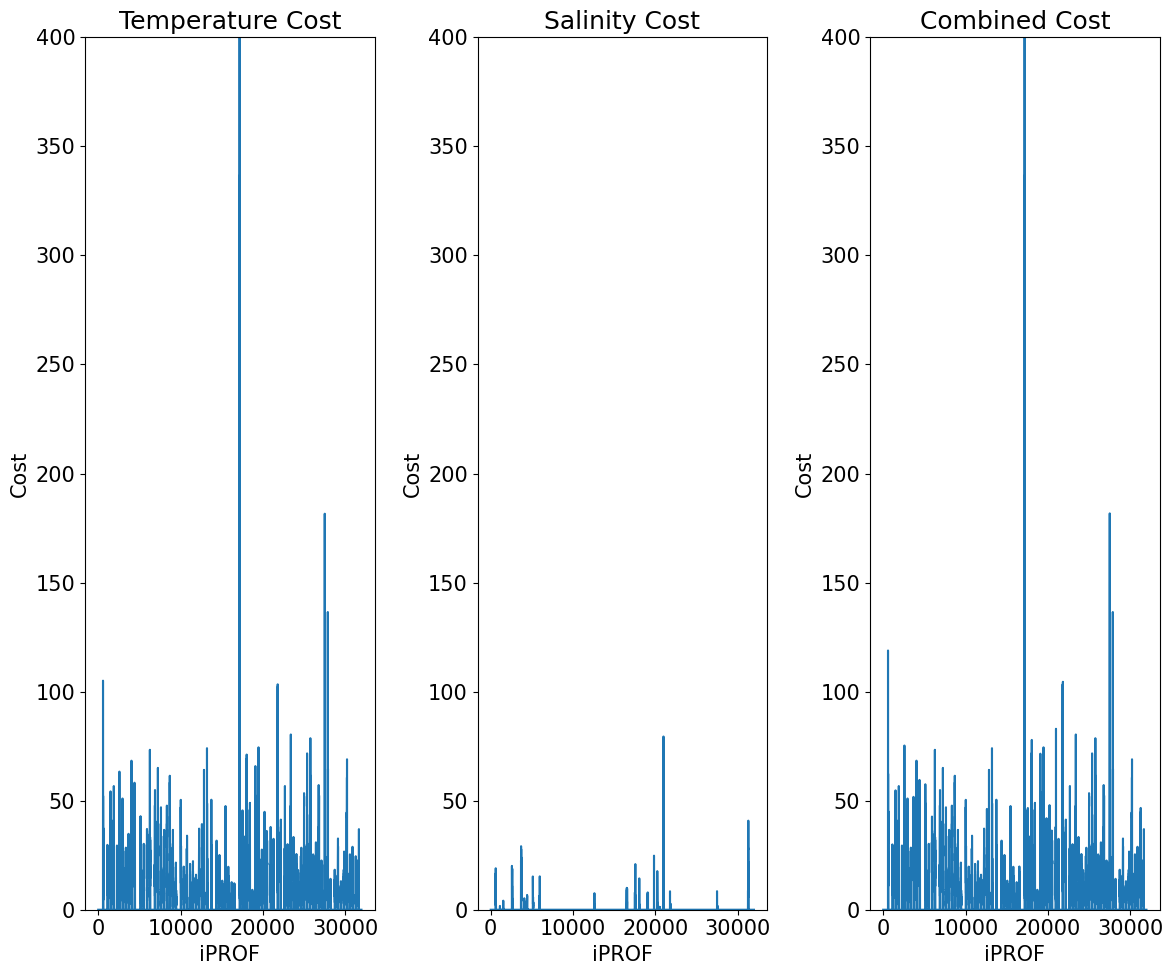

In [20]:
fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(12,10))
J_T.plot(ax=ax[0])
ax[0].set_ylim(0,400)
ax[0].set_title('Temperature Cost')
ax[0].set_ylabel('Cost')
J_S.plot(ax=ax[1])
ax[1].set_ylim(0,400)
ax[1].set_title('Salinity Cost')
ax[1].set_ylabel('Cost')
J_TS.plot(ax=ax[2])
ax[2].set_ylim(0,400)
ax[2].set_title('Combined Cost')
ax[2].set_ylabel('Cost')
plt.tight_layout()
fig.savefig(foldername + 'TAO_profile_costs_iter' + str(iter) + '.png')

<DatasetGroupBy, grouped over 2 grouper(s), 64 groups in total:
    'lon': UniqueGrouper('lon'), 8/8 groups with labels -170.0, -155.0, ..., 165.0, 180.0
    'lat': UniqueGrouper('lat'), 8/8 groups with labels -8.0, -5.0, -2.0, ..., 5.0, 8.0, 9.0>


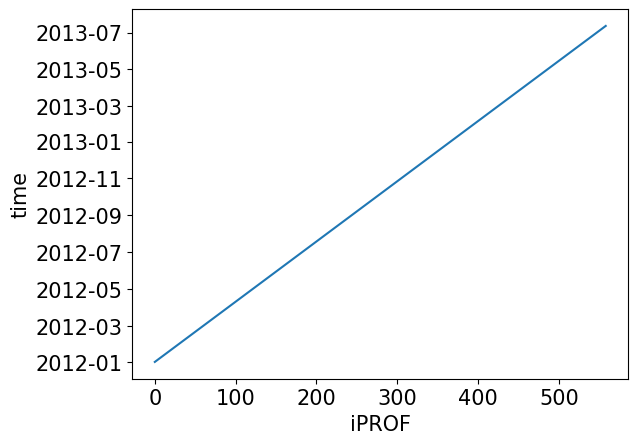

In [8]:
# group profiles by longitude (these are all equatorial TAO moorings)
ctd_by_loc = ds_ctd.groupby(['lon','lat'])
# check that for a single longitude, time is monotonically increasing 
print(ctd_by_loc)
ctd_by_loc[-140.0,0.0].sortby('time').time.plot()

In [9]:
len(np.unique(ctd_by_loc[-140.0,0.0].prof_T.time))

559

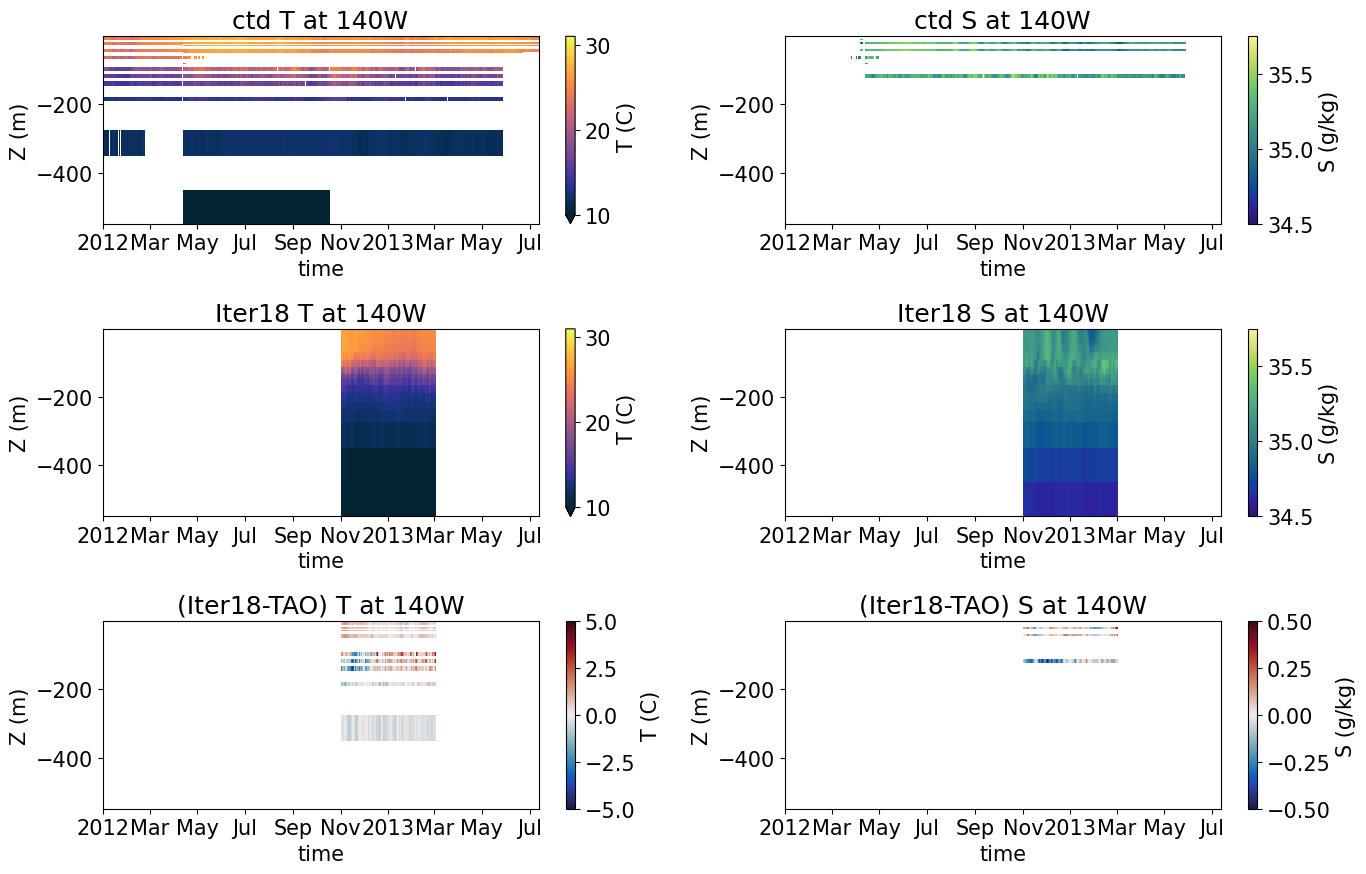

In [10]:
fig, ax = plt.subplots(figsize=(14,9),nrows=3, ncols=2)
ctd_by_loc[-140.0,0.0].sortby('time').prof_T.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.thermal,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[0,0].set_title('ctd T at 140W')
ax[0,0].set_ylabel('Z (m)')
ctd_by_loc[-140.0,0.0].sortby('time').prof_Testim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.thermal,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' T at 140W')
diff = ctd_by_loc[-140.0,0.0].sortby('time').prof_Testim - ctd_by_loc[-140.0,0.0].sortby('time').prof_T
diff.plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-5,vmax=5,cbar_kwargs={'label': 'T (C)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) T at 140W')
ax[2,0].set_ylabel('Z (m)')

ctd_by_loc[-140.0,0.0].sortby('time').prof_S.plot(ax=ax[0,1],x='time',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[0,1].set_title('ctd S at 140W')
ax[0,1].set_ylabel('Z (m)')
ctd_by_loc[-140.0,0.0].sortby('time').prof_Sestim.plot(ax=ax[1,1],x='time',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[1,1].set_ylabel('Z (m)')
ax[1,1].set_title('Iter'+ str(iter)+' S at 140W')
diff = ctd_by_loc[-140.0,0.0].sortby('time').prof_Sestim - ctd_by_loc[-140.0,0.0].sortby('time').prof_S
diff.T.plot(ax=ax[2,1],x='time',y='depth',cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label': 'S (g/kg)'})
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) S at 140W')
ax[2,1].set_ylabel('Z (m)')

plt.tight_layout()
filename = foldername + 'ctd_profiles_vs_iter'+ str(iter)+'.png'
plt.savefig(filename)

In [11]:
def slice_by_time_keep_lon(group, start_time, end_time=None):
    """
    Slice a group (Dataset) by time without overwriting lon.
    
    group: xarray Dataset for a single lon
    start_time: np.datetime64 or string
    """
    # Boolean mask along the profile dimension (iPROF)
    mask = group.time >= np.datetime64(start_time)

    if end_time is not None:
        mask &= group.time <= np.datetime64(end_time)
    
    # Select the profiles, keep all coordinates intact
    return group.isel(iPROF=mask)

In [12]:
start_date = '2012-11-01'
end_date = '2013-03-01'

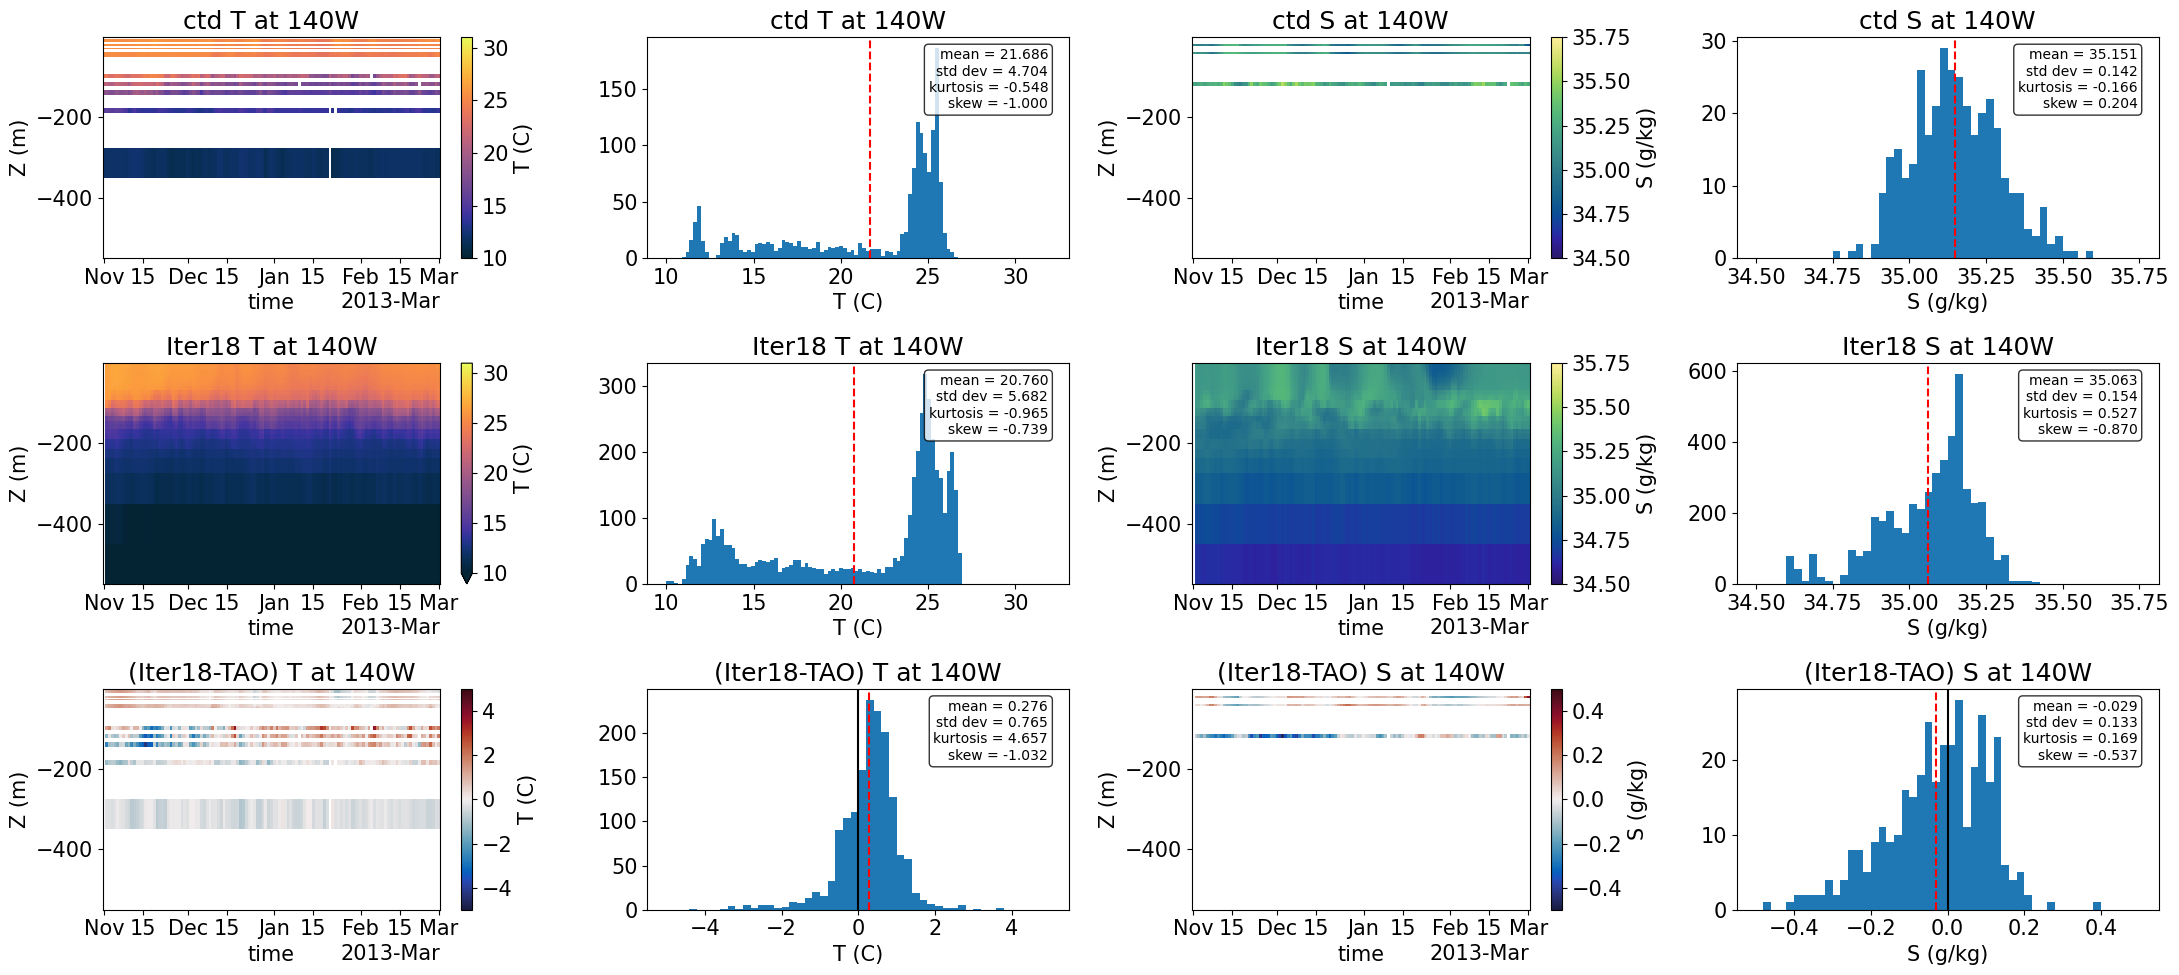

In [13]:
from scipy.stats import kurtosis, skew
vmin = 10.0
vmax = 32.0
nbins = 100

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-140.0,0.0].sortby('time'), start_date, end_date)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
ctd_by_loc_subset.prof_T.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.thermal,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[0,0].set_title('ctd T at 140W')
ax[0,0].set_ylabel('Z (m)')
ctd_by_loc_subset.prof_Testim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.thermal,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' T at 140W')
diff = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=-5,vmax=5,cbar_kwargs={'label': 'T (C)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) T at 140W')
ax[2,0].set_ylabel('Z (m)')


ctd_by_loc_subset.prof_T.plot.hist(ax=ax[0,1],bins=bins)
# ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ctd T at 140W')
ax[0,1].set_xlabel('T (C)')
mean_u = ctd_by_loc_subset.prof_T.mean().values
std_u = ctd_by_loc_subset.prof_T.std().values
flat_nonan = ctd_by_loc_subset.prof_T.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(mean_u,color='r', linestyle='--')

ctd_by_loc_subset.prof_Testim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' T at 140W')
# ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('T (C)')
mean_u = ctd_by_loc_subset.prof_Testim.mean().values
std_u = ctd_by_loc_subset.prof_Testim.std().values
flat_nonan = ctd_by_loc_subset.prof_Testim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(mean_u,color='r', linestyle='--')

vmin = -5.0
vmax = 5.0
nbins = 50
bins = np.linspace(vmin, vmax, nbins + 1)

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) T at 140W')
# ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('T (C)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = 34.5
vmax = 35.75
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

ctd_by_loc_subset.prof_S.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[0,2].set_title('ctd S at 140W')
ax[0,2].set_ylabel('Z (m)')
ctd_by_loc_subset.prof_Sestim.plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.haline,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' S at 140W')
diff = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=-0.5,vmax=0.5,cbar_kwargs={'label': 'S (g/kg)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) S at 140W')
ax[2,2].set_ylabel('Z (m)')


ctd_by_loc_subset.prof_S.plot.hist(ax=ax[0,3],bins=bins)
# ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ctd S at 140W')
ax[0,3].set_xlabel('S (g/kg)')
mean_u = ctd_by_loc_subset.prof_S.mean().values
std_u = ctd_by_loc_subset.prof_S.std().values
flat_nonan = ctd_by_loc_subset.prof_S.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(mean_u,color='r', linestyle='--')

ctd_by_loc_subset.prof_Sestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' S at 140W')
# ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('S (g/kg)')
mean_u = ctd_by_loc_subset.prof_Sestim.mean().values
std_u = ctd_by_loc_subset.prof_Sestim.std().values
flat_nonan = ctd_by_loc_subset.prof_Sestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(mean_u,color='r', linestyle='--')

vmin = -0.5
vmax = 0.5
nbins = 50
bins = np.linspace(vmin, vmax, nbins + 1)

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) S at 140W')
# ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('S (g/kg)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_hist_140W.png'
plt.savefig(filename)

In [14]:
print(ctd_by_loc_subset.depth)

<xarray.DataArray 'depth' (iDEPTH: 40)> Size: 320B
array([  -1.,   -2.,   -5.,  -10.,  -13.,  -15.,  -20.,  -25.,  -28.,
        -30.,  -31.,  -35.,  -40.,  -45.,  -48.,  -50.,  -51.,  -53.,
        -55.,  -60.,  -75.,  -80.,  -83., -100., -103., -120., -123.,
       -125., -140., -150., -153., -175., -180., -200., -203., -225.,
       -250., -300., -400., -500.])
Coordinates:
    depth    (iDEPTH) float64 320B -1.0 -2.0 -5.0 -10.0 ... -300.0 -400.0 -500.0
Dimensions without coordinates: iDEPTH


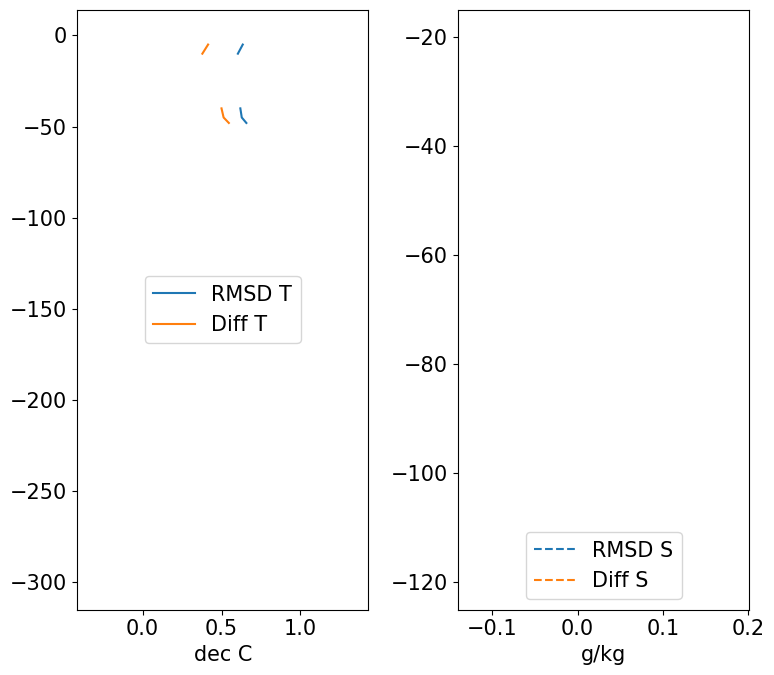

In [15]:
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-140.0,0.0].sortby('time'),start_date, end_date)
diffT = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diffS = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

rms_diffT = np.sqrt(np.nanmean((diffT**2),axis=0))
rms_diffS = np.sqrt(np.nanmean((diffS**2),axis=0))

fig, ax = plt.subplots(figsize=(8,7), ncols=2)
ax[0].plot(rms_diffT,ctd_by_loc_subset.depth,label='RMSD T')
ax[1].plot(rms_diffS,ctd_by_loc_subset.depth,label='RMSD S',linestyle='--')
ax[0].plot(np.nanmean(diffT,axis=0),ctd_by_loc_subset.depth,label='Diff T')
ax[1].plot(np.nanmean(diffS,axis=0),ctd_by_loc_subset.depth,label='Diff S',linestyle='--')
ax[0].set_xlabel('dec C')
ax[0].legend()
ax[1].set_xlabel('g/kg')
ax[1].legend()
plt.tight_layout()

filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_RMSE_140W.png'
plt.savefig(filename)

TypeError: No numeric data to plot.

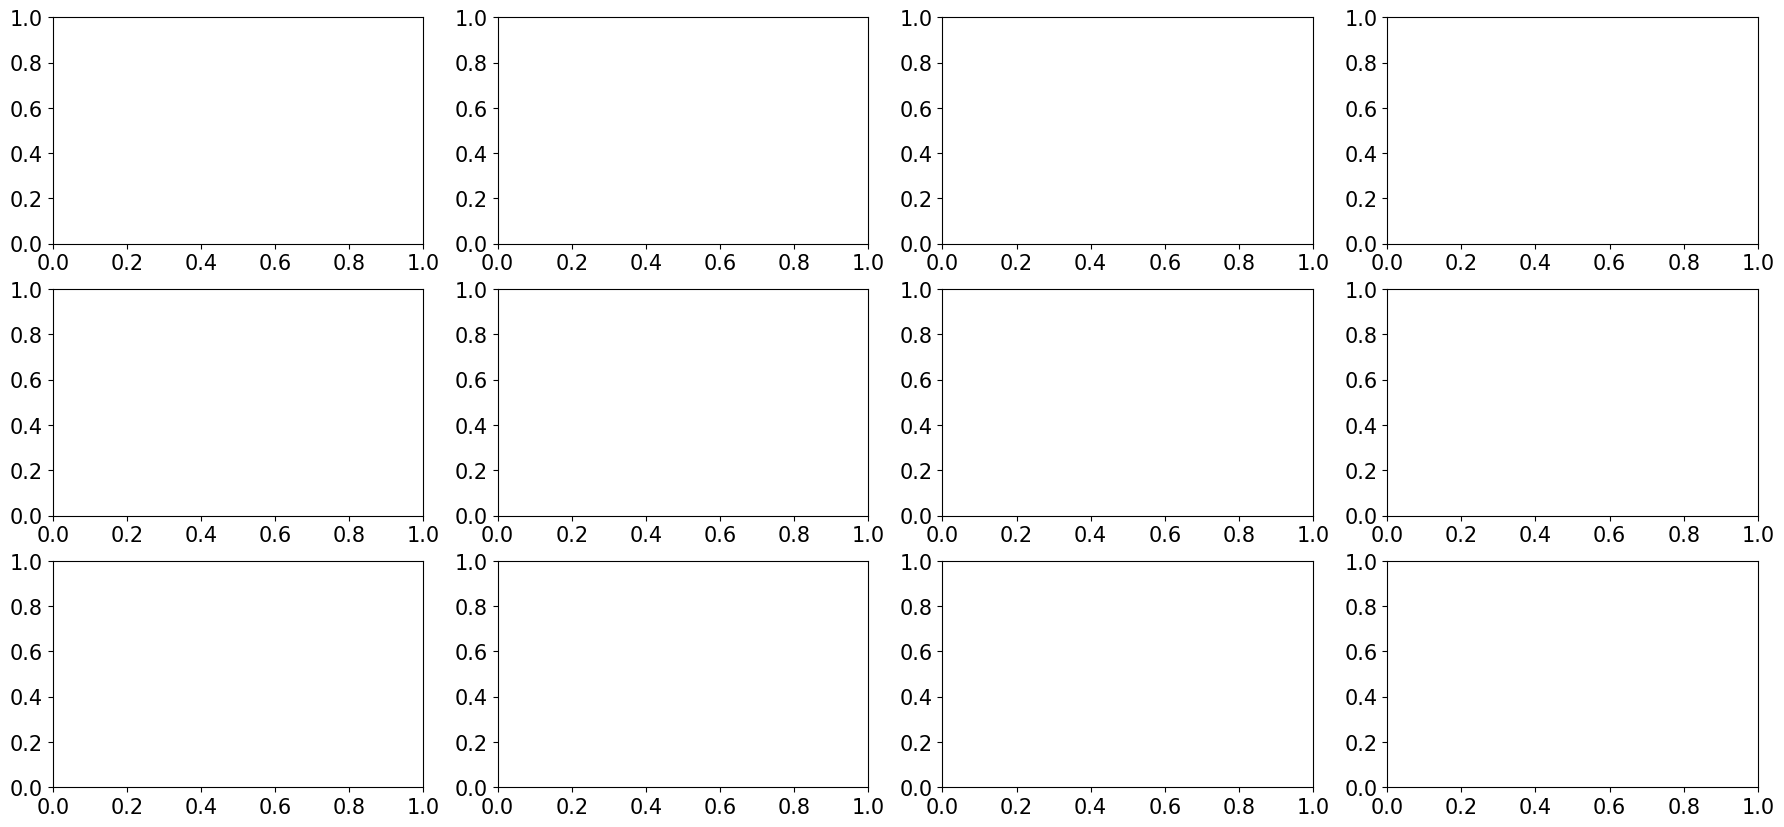

In [16]:
from scipy.stats import kurtosis, skew
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-110.0,0.0].sortby('time'),start_date, end_date)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
ctd_by_loc_subset.prof_T.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[0,0].set_title('ctd T at 110W')
ax[0,0].set_ylabel('Z (m)')
ctd_by_loc_subset.prof_Testim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' T at 110W')
diff = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) T at 110W')
ax[2,0].set_ylabel('Z (m)')


ctd_by_loc_subset.prof_T.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ctd T at 110W')
ax[0,1].set_xlabel('T (C)')
mean_u = ctd_by_loc_subset.prof_T.mean().values
std_u = ctd_by_loc_subset.prof_T.std().values
flat_nonan = ctd_by_loc_subset.prof_T.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

ctd_by_loc_subset.prof_Testim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' T at 110W')
ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('T (C)')
mean_u = ctd_by_loc_subset.prof_Testim.mean().values
std_u = ctd_by_loc_subset.prof_Testim.std().values
flat_nonan = ctd_by_loc_subset.prof_Testim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) T at 110W')
ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('T (C)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

ctd_by_loc_subset.prof_S.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.balance,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[0,2].set_title('ctd S at 110W')
ax[0,2].set_ylabel('Z (m)')
ctd_by_loc_subset.prof_Sestim.plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.balance,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' S at 110W')
diff = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) S at 110W')
ax[2,2].set_ylabel('Z (m)')


ctd_by_loc_subset.prof_S.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ctd S at 110W')
ax[0,3].set_xlabel('S (g/kg)')
mean_u = ctd_by_loc_subset.prof_S.mean().values
std_u = ctd_by_loc_subset.prof_S.std().values
flat_nonan = ctd_by_loc_subset.prof_S.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

ctd_by_loc_subset.prof_Sestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' S at 110W')
ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('S (g/kg)')
mean_u = ctd_by_loc_subset.prof_Sestim.mean().values
std_u = ctd_by_loc_subset.prof_Sestim.std().values
flat_nonan = ctd_by_loc_subset.prof_Sestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) S at 110W')
ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('S (g/kg)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_hist_110W.png'
plt.savefig(filename)

In [ ]:
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-110.0,0.0].sortby('time'),start_date, end_date)
diffT = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diffS = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

rms_diffT = np.sqrt((diffT**2).mean(axis=0))
rms_diffS = np.sqrt((diffS**2).mean(axis=0))

fig, ax = plt.subplots(figsize=(5,7))
ax.plot(rms_diffT,ctd_by_loc_subset.depth,label='RMSD T')
ax.plot(rms_diffS,ctd_by_loc_subset.depth,label='RMSD S',linestyle='--')
ax.plot(diffT.mean(axis=0),ctd_by_loc_subset.depth,label='Diff T')
ax.plot(diffS.mean(axis=0),ctd_by_loc_subset.depth,label='Diff S',linestyle='--')
ax.axvline(0, color='k', linewidth=0.75)
ax.axvline(0.05, color='k', linestyle=':',linewidth=0.75)
ax.set_xlim(-0.3,0.3)
ax.set_xlabel('m/s')
ax.legend()
plt.tight_layout()

filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_RMSE_110W.png'
plt.savefig(filename)

In [ ]:
from scipy.stats import kurtosis, skew
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-170.0,0.0].sortby('time'),start_date, end_date)

fig, ax = plt.subplots(figsize=(22,10),nrows=3, ncols=4)
ctd_by_loc_subset.prof_T.plot(ax=ax[0,0],x='time',y='depth',cmap=cmo.balance,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[0,0].set_title('ctd T at 170W')
ax[0,0].set_ylabel('Z (m)')
ctd_by_loc_subset.prof_Testim.plot(ax=ax[1,0],x='time',y='depth',cmap=cmo.balance,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[1,0].set_ylabel('Z (m)')
ax[1,0].set_title('Iter'+ str(iter)+' T at 170W')
diff = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diff[:].plot(ax=ax[2,0],x='time',y='depth',cmap=cmo.balance,vmin=10,vmax=31,cbar_kwargs={'label': 'T (C)'})
ax[2,0].set_title('(Iter'+ str(iter)+'-TAO) T at 170W')
ax[2,0].set_ylabel('Z (m)')


ctd_by_loc_subset.prof_T.plot.hist(ax=ax[0,1],bins=bins)
ax[0,1].set_ylim(0,25000)
ax[0,1].set_title('ctd T at 170W')
ax[0,1].set_xlabel('T (C)')
mean_u = ctd_by_loc_subset.prof_T.mean().values
std_u = ctd_by_loc_subset.prof_T.std().values
flat_nonan = ctd_by_loc_subset.prof_T.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,1].text(
    0.95, 0.95, textstr,
    transform=ax[0,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,1].axvline(0.0,color='k')
ax[0,1].axvline(mean_u,color='r', linestyle='--')

ctd_by_loc_subset.prof_Testim.plot.hist(ax=ax[1,1],bins=bins)
ax[1,1].set_title('Iter'+ str(iter)+' T at 170W')
ax[1,1].set_ylim(0,25000)
ax[1,1].set_xlabel('T (C)')
mean_u = ctd_by_loc_subset.prof_Testim.mean().values
std_u = ctd_by_loc_subset.prof_Testim.std().values
flat_nonan = ctd_by_loc_subset.prof_Testim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,1].text(
    0.95, 0.95, textstr,
    transform=ax[1,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,1].axvline(0.0,color='k')
ax[1,1].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,1],bins=bins)
ax[2,1].set_title('(Iter'+ str(iter)+'-TAO) T at 170W')
ax[2,1].set_ylim(0,30000)
ax[2,1].set_xlabel('T (C)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,1].text(
    0.95, 0.95, textstr,
    transform=ax[2,1].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,1].axvline(0.0,color='k')
ax[2,1].axvline(mean_u,color='r', linestyle='--')

# ------------- V ------------
vmin = -1.25
vmax = 1.25
nbins = 50

# Create bin edges
bins = np.linspace(vmin, vmax, nbins + 1)

ctd_by_loc_subset.prof_S.plot(ax=ax[0,2],x='time',y='depth',cmap=cmo.balance,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[0,2].set_title('ctd S at 170W')
ax[0,2].set_ylabel('Z (m)')
ctd_by_loc_subset.prof_Sestim.plot(ax=ax[1,2],x='time',y='depth',cmap=cmo.balance,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[1,2].set_ylabel('Z (m)')
ax[1,2].set_title('Iter'+ str(iter)+' S at 170W')
diff = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S
diff[:].plot(ax=ax[2,2],x='time',y='depth',cmap=cmo.balance,vmin=34.5,vmax=35.75,cbar_kwargs={'label': 'S (g/kg)'})
ax[2,2].set_title('(Iter'+ str(iter)+'-TAO) S at 170W')
ax[2,2].set_ylabel('Z (m)')


ctd_by_loc_subset.prof_S.plot.hist(ax=ax[0,3],bins=bins)
ax[0,3].set_ylim(0,30000)
ax[0,3].set_title('ctd S at 170W')
ax[0,3].set_xlabel('S (g/kg)')
mean_u = ctd_by_loc_subset.prof_S.mean().values
std_u = ctd_by_loc_subset.prof_S.std().values
flat_nonan = ctd_by_loc_subset.prof_S.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[0,3].text(
    0.95, 0.95, textstr,
    transform=ax[0,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[0,3].axvline(0.0,color='k')
ax[0,3].axvline(mean_u,color='r', linestyle='--')

ctd_by_loc_subset.prof_Sestim.plot.hist(ax=ax[1,3],bins=bins)
ax[1,3].set_title('Iter'+ str(iter)+' S at 170W')
ax[1,3].set_ylim(0,30000)
ax[1,3].set_xlabel('S (g/kg)')
mean_u = ctd_by_loc_subset.prof_Sestim.mean().values
std_u = ctd_by_loc_subset.prof_Sestim.std().values
flat_nonan = ctd_by_loc_subset.prof_Sestim.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[1,3].text(
    0.95, 0.95, textstr,
    transform=ax[1,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[1,3].axvline(0.0,color='k')
ax[1,3].axvline(mean_u,color='r', linestyle='--')

diff.plot.hist(ax=ax[2,3],bins=bins)
ax[2,3].set_title('(Iter'+ str(iter)+'-TAO) S at 170W')
ax[2,3].set_ylim(0,30000)
ax[2,3].set_xlabel('S (g/kg)')
mean_u = diff.mean().values
std_u = diff.std().values
flat_nonan = diff.values.flatten()
flat_nonan = flat_nonan[~np.isnan(flat_nonan)]
kurt_u = kurtosis(flat_nonan,axis=None)
skew_u = skew(flat_nonan,axis=None)
# Format text
textstr = f"mean = {mean_u:.3f}\nstd dev = {std_u:.3f}\nkurtosis = {kurt_u:.3f}\nskew = {skew_u:.3f}"

# Add text box
ax[2,3].text(
    0.95, 0.95, textstr,
    transform=ax[2,3].transAxes,  # axes fraction
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
ax[2,3].axvline(0.0,color='k')
ax[2,3].axvline(mean_u,color='r', linestyle='--')

plt.tight_layout()
filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_hist_170W.png'
plt.savefig(filename)

In [ ]:
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-170.0,0.0].sortby('time'),start_date, end_date)
diffT = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diffS = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

rms_diffT = np.sqrt((diffT**2).mean(axis=0))
rms_diffS = np.sqrt((diffS**2).mean(axis=0))

fig, ax = plt.subplots(figsize=(5,7))
ax.plot(rms_diffT,ctd_by_loc_subset.depth,label='RMSD T')
ax.plot(rms_diffS,ctd_by_loc_subset.depth,label='RMSD S',linestyle='--')
ax.plot(diffT.mean(axis=0),ctd_by_loc_subset.depth,label='Diff T')
ax.plot(diffS.mean(axis=0),ctd_by_loc_subset.depth,label='Diff S',linestyle='--')
ax.axvline(0, color='k', linewidth=0.75)
ax.axvline(0.05, color='k', linestyle=':',linewidth=0.75)
ax.set_xlim(-0.3,0.3)
ax.set_xlabel('m/s')
ax.legend()
plt.tight_layout()

filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_RMSE_170W.png'
plt.savefig(filename)

In [ ]:
# Initialize the values array
uncertainty = np.zeros_like(ctd_by_loc_subset.depth, dtype=float)

# Region 1: Above 25 m (depth > -25 since depths are negative)
uncertainty[ctd_by_loc_subset.depth > -25] = 0.2

# Region 2: Between 25m and 150m (depth between -150 and -25)
mask = (ctd_by_loc_subset.depth <= -25) & (ctd_by_loc_subset.depth >= -150)
# Linear interpolation from 0.2 at -25 to 0.07 at -150
uncertainty[mask] = 0.2 + (0.08 - 0.2) * (ctd_by_loc_subset.depth[mask] + 25) / (-150 + 25)

# Region 3: Below 150m (depth < -150)
uncertainty[ctd_by_loc_subset.depth < -150] = 0.08

In [ ]:
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-170.0,0.0].sortby('time'),start_date, end_date)
diffT = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diffS = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

rms_diffT = np.sqrt((diffT**2).mean(axis=0))
rms_diffS = np.sqrt((diffS**2).mean(axis=0))

plt.rcParams['font.size'] = 13

fig, ax = plt.subplots(figsize=(10,7),ncols=3)
ax[0].plot(rms_diffT,ctd_by_loc_subset.depth,label='RMSD T')
ax[0].plot(rms_diffS,ctd_by_loc_subset.depth,label='RMSD S',linestyle='--')
ax[0].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=':')
# ax[0].plot(diffT.mean(axis=0),ctd_by_loc_subset.depth,label='Diff T')
# ax[0].plot(diffS.mean(axis=0),ctd_by_loc_subset.depth,label='Diff S',linestyle='--')
ax[0].axvline(0, color='k', linewidth=0.75)
# ax[0].axvline(0.05, color='k', linestyle=':',linewidth=0.75)
# ax[0].axvline(np.max(np.abs(diffT)),color='r', linestyle=':')
# ax[0].axvline(np.max(np.abs(diffS)),color='g', linestyle=':')
# ax[0].axvline(np.min(np.abs(diffT)),color='m', linestyle=':')
# ax[0].axvline(np.min(np.abs(diffS)),color='c', linestyle=':')
ax[0].set_xlim(-0.3,0.5)
ax[0].set_xlabel('m/s')
ax[0].legend()
ax[0].set_title('170W')
ax[0].set_ylim(-300,0)

ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-140.0,0.0].sortby('time'), start_date, end_date)
diffT = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diffS = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

rms_diffT = np.sqrt((diffT**2).mean(axis=0))
rms_diffS = np.sqrt((diffS**2).mean(axis=0))

ax[1].plot(rms_diffT,ctd_by_loc_subset.depth,label='RMSD T')
ax[1].plot(rms_diffS,ctd_by_loc_subset.depth,label='RMSD S',linestyle='--')
ax[1].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=':')
# ax[1].plot(diffT.mean(axis=0),ctd_by_loc_subset.depth,label='Diff T')
# ax[1].plot(diffS.mean(axis=0),ctd_by_loc_subset.depth,label='Diff S',linestyle='--')
ax[1].axvline(0, color='k', linewidth=0.75)
# ax[1].axvline(0.05, color='k', linestyle=':',linewidth=0.75)
# ax[1].axvline(np.max(np.abs(diffT)),color='r', linestyle=':')
# ax[1].axvline(np.max(np.abs(diffS)),color='g', linestyle=':')
# ax[1].axvline(np.min(np.abs(diffT)),color='m', linestyle=':')
# ax[1].axvline(np.min(np.abs(diffS)),color='c', linestyle=':')
ax[1].set_xlim(-0.3,0.5)
ax[1].set_xlabel('m/s')
ax[1].set_title('140W')
ax[1].set_ylim(-300,0)

ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-110.0,0.0].sortby('time'),start_date, end_date)
diffT = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diffS = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

rms_diffT = np.sqrt((diffT**2).mean(axis=0))
rms_diffS = np.sqrt((diffS**2).mean(axis=0))

ax[2].plot(rms_diffT,ctd_by_loc_subset.depth,label='RMSD T')
ax[2].plot(rms_diffS,ctd_by_loc_subset.depth,label='RMSD S',linestyle='--')
ax[2].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=':')
# ax[2].plot(diffT.mean(axis=0),ctd_by_loc_subset.depth,label='Diff T')
# ax[2].plot(diffS.mean(axis=0),ctd_by_loc_subset.depth,label='Diff S',linestyle='--')
ax[2].axvline(0, color='k', linewidth=0.75)
# ax[2].axvline(0.05, color='k', linestyle=':',linewidth=0.75)
# ax[2].axvline(np.max(np.abs(diffT)),color='r', linestyle=':')
# ax[2].axvline(np.max(np.abs(diffS)),color='g', linestyle=':')
# ax[2].axvline(np.min(np.abs(diffT)),color='m', linestyle=':')
# ax[2].axvline(np.min(np.abs(diffS)),color='c', linestyle=':')
ax[2].set_xlim(-0.3,0.5)
ax[2].set_xlabel('m/s')
ax[2].set_title('110W')
ax[2].set_ylim(-300,0)

plt.tight_layout()

filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_RMSE.png'
plt.savefig(filename)

In [ ]:
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-170.0,0.0].sortby('time'),start_date, end_date)

plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(10,7),ncols=3)
ax[0].plot(ctd_by_loc_subset.isel(iPROF=1).prof_Testim,ctd_by_loc_subset.depth,label='TPOSE U')
ax[0].plot(ctd_by_loc_subset.isel(iPROF=1).prof_T,ctd_by_loc_subset.depth,label='ctd U',linestyle='--')
ax[0].plot(ctd_by_loc_subset.isel(iPROF=1).prof_Sestim,ctd_by_loc_subset.depth,label='TPOSE V')
ax[0].plot(ctd_by_loc_subset.isel(iPROF=1).prof_S,ctd_by_loc_subset.depth,label='ctd V',linestyle='--')
# ax[0].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=':')
ax[0].axvline(0, color='k', linewidth=0.75)
ax[0].set_xlim(-1.5,1.5)
ax[0].set_xlabel('m/s')
ax[0].legend()
ax[0].set_title('170W')
ax[0].set_ylim(-300,0)

ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-140.0,0.0].sortby('time'),start_date, end_date)

ax[1].plot(ctd_by_loc_subset.isel(iPROF=1).prof_Testim,ctd_by_loc_subset.depth,label='TPOSE U')
ax[1].plot(ctd_by_loc_subset.isel(iPROF=1).prof_T,ctd_by_loc_subset.depth,label='ctd U',linestyle='--')
ax[1].plot(ctd_by_loc_subset.isel(iPROF=1).prof_Sestim,ctd_by_loc_subset.depth,label='TPOSE V')
ax[1].plot(ctd_by_loc_subset.isel(iPROF=1).prof_S,ctd_by_loc_subset.depth,label='ctd V',linestyle='--')
# ax[1].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=':')
ax[1].axvline(0, color='k', linewidth=0.75)
ax[1].set_xlim(-1.5,1.5)
ax[1].set_xlabel('m/s')
ax[1].set_title('140W')
ax[1].set_ylim(-300,0)

ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-110.0,0.0].sortby('time'),start_date, end_date)

ax[2].plot(ctd_by_loc_subset.isel(iPROF=1).prof_Testim,ctd_by_loc_subset.depth,label='TPOSE U')
ax[2].plot(ctd_by_loc_subset.isel(iPROF=1).prof_T,ctd_by_loc_subset.depth,label='ctd U',linestyle='--')
ax[2].plot(ctd_by_loc_subset.isel(iPROF=1).prof_Sestim,ctd_by_loc_subset.depth,label='TPOSE V')
ax[2].plot(ctd_by_loc_subset.isel(iPROF=1).prof_S,ctd_by_loc_subset.depth,label='ctd V',linestyle='--')
# ax[2].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=' :')
ax[2].axvline(0, color='k', linewidth=0.75)
ax[2].set_xlim(-1.5,1.5)
ax[2].set_xlabel('m/s')
ax[2].set_title('110W')
ax[2].set_ylim(-300,0)

plt.tight_layout()

filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_RMSE_timestep0.png'
plt.savefig(filename)

In [ ]:
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-170.0,0.0].sortby('time'),start_date, end_date)

plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(10,7),ncols=3)
ax[0].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_Testim,ctd_by_loc_subset.depth,label='TPOSE U')
ax[0].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_T,ctd_by_loc_subset.depth,label='ctd U',linestyle='--')
ax[0].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_Sestim,ctd_by_loc_subset.depth,label='TPOSE V')
ax[0].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_S,ctd_by_loc_subset.depth,label='ctd V',linestyle='--')
# ax[0].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=':')
ax[0].axvline(0, color='k', linewidth=0.75)
ax[0].set_xlim(-1.5,1.5)
ax[0].set_xlabel('m/s')
ax[0].legend()
ax[0].set_title('170W')
ax[0].set_ylim(-300,0)

ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-140.0,0.0].sortby('time'),start_date, end_date)

ax[1].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_Testim,ctd_by_loc_subset.depth,label='TPOSE U')
ax[1].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_T,ctd_by_loc_subset.depth,label='ctd U',linestyle='--')
ax[1].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_Sestim,ctd_by_loc_subset.depth,label='TPOSE V')
ax[1].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_S,ctd_by_loc_subset.depth,label='ctd V',linestyle='--')
# ax[1].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=':')
ax[1].axvline(0, color='k', linewidth=0.75)
ax[1].set_xlim(-1.5,1.5)
ax[1].set_xlabel('m/s')
ax[1].set_title('140W')
ax[1].set_ylim(-300,0)

ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-110.0,0.0].sortby('time'),start_date, end_date)

ax[2].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_Testim,ctd_by_loc_subset.depth,label='TPOSE U')
ax[2].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_T,ctd_by_loc_subset.depth,label='ctd U',linestyle='--')
ax[2].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_Sestim,ctd_by_loc_subset.depth,label='TPOSE V')
ax[2].plot(ctd_by_loc_subset.isel(iPROF=-1).prof_S,ctd_by_loc_subset.depth,label='ctd V',linestyle='--')
# ax[2].plot(uncertainty,ctd_by_loc_subset.depth,label='Data Std Dev',linestyle=' :')
ax[2].axvline(0, color='k', linewidth=0.75)
ax[2].set_xlim(-1.5,1.5)
ax[2].set_xlabel('m/s')
ax[2].set_title('110W')
ax[2].set_ylim(-300,0)

plt.tight_layout()

filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_RMSE_timestepN.png'
plt.savefig(filename)

### Velocity Bias Over Time

In [ ]:
plt.rcParams['font.size'] = 13
ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-170.0,0.0].sortby('time'),start_date, end_date)

diff_U = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diff_V = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

# take rolling mean to smooth time series
rms_diffT = np.sqrt((diff_U**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
rms_diffS = np.sqrt((diff_V**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
std_diffT = diff_U.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()
std_diffS = diff_V.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()

start_string = pd.to_datetime(start_date)
end_string = pd.to_datetime(end_date)

fig, ax = plt.subplots(figsize=(10,15),nrows=3)
ax[0].plot(ctd_by_loc_subset.time, rms_diffT, color='tab:blue', label='RMSD T')
ax[0].plot(ctd_by_loc_subset.time, rms_diffS, color='tab:orange', label='RMSD S')
ax[0].fill_between(ctd_by_loc_subset.time, rms_diffT-std_diffT, rms_diffT+std_diffT, color='tab:blue', alpha=0.3, label='_nolabel_')
ax[0].fill_between(ctd_by_loc_subset.time, rms_diffS-std_diffS, rms_diffS+std_diffS, color='tab:orange', alpha=0.3, label='_nolabel_')
ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_ylabel('m/s')
ax[0].set_title('RMSD Time Series at 170W')
ax[0].legend()
ax[0].set_ylim(0,1.0)
ax[0].set_xlim(start_string, end_string)

ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-140.0,0.0].sortby('time'),start_date, end_date)

diff_U = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diff_V = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

# take rolling mean to smooth time series
rms_diffT = np.sqrt((diff_U**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
rms_diffS = np.sqrt((diff_V**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
std_diffT = diff_U.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()
std_diffS = diff_V.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()

ax[1].plot(ctd_by_loc_subset.time, rms_diffT, color='tab:blue', label='RMSD T')
ax[1].plot(ctd_by_loc_subset.time, rms_diffS, color='tab:orange', label='RMSD S')
ax[1].fill_between(ctd_by_loc_subset.time, rms_diffT-std_diffT, rms_diffT+std_diffT, color='tab:blue', alpha=0.3, label='_nolabel_')
ax[1].fill_between(ctd_by_loc_subset.time, rms_diffS-std_diffS, rms_diffS+std_diffS, color='tab:orange', alpha=0.3, label='_nolabel_')
ax[1].set_xlabel('')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_ylabel('m/s')
ax[1].set_title('RMSD Time Series at 140W')
ax[1].legend()
ax[1].set_ylim(0,1.0)
ax[1].set_xlim(start_string, end_string)

ctd_by_loc_subset = slice_by_time_keep_lon(ctd_by_loc[-110.0,0.0].sortby('time'),start_date, end_date)

diff_U = ctd_by_loc_subset.prof_Testim - ctd_by_loc_subset.prof_T
diff_V = ctd_by_loc_subset.prof_Sestim - ctd_by_loc_subset.prof_S

# take rolling mean to smooth time series
rms_diffT = np.sqrt((diff_U**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
rms_diffS = np.sqrt((diff_V**2).mean(dim='iDEPTH')).rolling(iPROF=100,center=True).mean()
std_diffT = diff_U.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()
std_diffS = diff_V.std(dim='iDEPTH').rolling(iPROF=100,center=True).mean()

ax[2].plot(ctd_by_loc_subset.time, rms_diffT, color='tab:blue', label='RMSD T')
ax[2].plot(ctd_by_loc_subset.time, rms_diffS, color='tab:orange', label='RMSD S')
ax[2].fill_between(ctd_by_loc_subset.time, rms_diffT-std_diffT, rms_diffT+std_diffT, color='tab:blue', alpha=0.3, label='_nolabel_')
ax[2].fill_between(ctd_by_loc_subset.time, rms_diffS-std_diffS, rms_diffS+std_diffS, color='tab:orange', alpha=0.3, label='_nolabel_')
ax[2].set_xlabel('')
ax[2].tick_params(axis='x', rotation=45)
ax[2].set_ylabel('m/s')
ax[2].set_title('RMSD Time Series at 110W')
ax[2].legend()
ax[2].set_ylim(0,1.0)
ax[2].set_xlim(start_string, end_string)

plt.tight_layout()
filename = foldername + 'ctd_TS_vs_Iter' + str(iter) + '_bias_time_series.png'
plt.savefig(filename)


In [ ]:
client.shutdown()
cluster.close()
client.close()